# # 04 - Empathy & Inclusivity Scoring
 **Project:** AI-Based Media Empathy Analyzer  
 **Objective:** Utilize Zero-Shot Classification to detect complex interpersonal dynamics (empathy, condescension, supportiveness) and generate a final Inclusivity Score for characters and media.


In [1]:
# ## 1. Imports & Setup
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from transformers import pipeline

# Register tqdm with pandas
tqdm.pandas()
warnings.filterwarnings('ignore')


# ## 2. Configuration

In [2]:
BASE_DIR = Path(r"D:\project\NLP")

PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
INPUT_FILE = PROCESSED_DATA_DIR / "dialogues_with_features.csv"
OUTPUT_FILE = PROCESSED_DATA_DIR / "dialogues_final_scored.csv"

# Zero-Shot Model Configuration
# BART-large is the industry standard for highly accurate zero-shot classification
ZERO_SHOT_MODEL = "facebook/bart-large-mnli"

# Define our labels for Inclusivity/Empathy analysis
POSITIVE_LABELS = ["empathetic", "supportive", "respectful"]
NEGATIVE_LABELS = ["condescending", "dismissive", "mocking"]
ALL_LABELS = POSITIVE_LABELS + NEGATIVE_LABELS

# ## 3. Loading Data & Optimization

In [3]:
print(f"Loading data from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)
df.dropna(subset=['Dialogue'], inplace=True)

initial_count = len(df)

# OPTIMIZATION: Zero-shot is computationally expensive.
# We will drop lines with fewer than 5 words, as they lack enough context 
# to accurately judge "empathy" or "condescension" (e.g., "Yeah.", "No.", "Hi.").
df = df[df['Word_Count'] >= 5]
df.reset_index(drop=True, inplace=True)

print(f"Filtered out extremely short lines.")
print(f"Remaining lines to process: {len(df)} (out of {initial_count})")


Loading data from D:\project\NLP\data\processed\dialogues_with_features.csv...
Filtered out extremely short lines.
Remaining lines to process: 203 (out of 204)


# ## 4. Loading the Zero-Shot Pipeline

In [4]:
print(f"Loading Zero-Shot Classifier: {ZERO_SHOT_MODEL}...")
try:
    import torch
    device = 0 if torch.cuda.is_available() else -1
    print(f"Using device: {'GPU' if device == 0 else 'CPU'}")
except ImportError:
    device = -1
    print("PyTorch not found. Using CPU.")

classifier = pipeline(
    "zero-shot-classification", 
    model=ZERO_SHOT_MODEL, 
    device=device
)


Loading Zero-Shot Classifier: facebook/bart-large-mnli...
Using device: CPU


Device set to use cpu


# ## 5. Empathy Scoring Logic

In [5]:
def score_inclusivity(text: str) -> dict:
    """
    Runs zero-shot classification on a text line to assign scores 
    to specific empathetic and ableist/hostile traits.
    
    Args:
        text (str): The dialogue text.
        
    Returns:
        dict: A dictionary of the traits and their confidence scores.
    """
    try:
        result = classifier(text, candidate_labels=ALL_LABELS, multi_label=True)
        # Zip labels and scores into a dictionary
        scores = dict(zip(result['labels'], result['scores']))
        
        # Calculate aggregate scores
        positive_score = sum(scores[label] for label in POSITIVE_LABELS)
        negative_score = sum(scores[label] for label in NEGATIVE_LABELS)
        
        # Empathy metric: (Positive traits) - (Negative traits)
        # Range theoretically from -3.0 to +3.0
        empathy_score = positive_score - negative_score
        
        scores['Empathy_Score'] = empathy_score
        # Identify the dominant trait
        scores['Dominant_Trait'] = max(scores, key=lambda k: scores[k] if k in ALL_LABELS else -1)
        
        return scores
    
    except Exception as e:
        # Fallback for unexpected tokenization errors
        return {label: 0.0 for label in ALL_LABELS} | {'Empathy_Score': 0.0, 'Dominant_Trait': 'None'}

# ## 6. Processing the Dataset
 *Note: Depending on your CPU/GPU, this may take a while. We process in batches for safety.*


In [6]:
print("Applying Zero-Shot Classification. Grab a coffee, this will take some time...")

# For demonstration and speed, we will process the top 1000 longest/most complex lines first.
# If you want to process the ENTIRE script, change this to: sample_df = df.copy()
print("Sampling the top 1000 most complex lines for deep analysis...")
sample_df = df.sort_values(by='Word_Count', ascending=False).head(1000).copy()

# Apply the classifier
scored_results = sample_df['Dialogue'].progress_apply(score_inclusivity)
scored_df = pd.DataFrame(scored_results.tolist())

# Merge the scores back into our sample dataframe
final_df = pd.concat([sample_df.reset_index(drop=True), scored_df], axis=1)


Applying Zero-Shot Classification. Grab a coffee, this will take some time...
Sampling the top 1000 most complex lines for deep analysis...


  0%|          | 0/203 [00:00<?, ?it/s]

# ## 7. Saving Final Output

In [7]:
print(f"Saving fully scored dataset to {OUTPUT_FILE}...")
final_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
print("Save complete!")

display(final_df[['Character', 'Dialogue', 'Dominant_Trait', 'Empathy_Score']].head(10))

Saving fully scored dataset to D:\project\NLP\data\processed\dialogues_final_scored.csv...
Save complete!


,Character,Dialogue,Dominant_Trait,Empathy_Score
0,467 LEIA I,"""468"" ""han"" ""ahhh..."" ""469"" ""han"" ""i'm sorry.""...",condescending,-0.259475
1,BATEMAN,"harold, it's bateman. patrick bateman. you're ...",empathetic,0.494699
2,BATEMAN V/O,"i believe in taking care of myself, in a balan...",supportive,2.383489
3,BATEMAN,"well, i could be wrong. well ....when was the ...",empathetic,1.731448
4,KIMBALL,"send him in, i guess. as she exits, he picks u...",respectful,0.648006
5,CUT TO,phil collins' solo efforts seem to be more com...,supportive,1.042106
6,BATEMAN,you have a really nice place here paul. how mu...,supportive,1.322901
7,BATEMAN,i can't... i can't find a shelter. you reek. y...,condescending,-1.162753
8,MCDERMOTT,but i never told you what happened afterwards....,condescending,-2.259623
9,BATEMAN,"oh, who gives a rat's ass? hey. that affects u...",dismissive,-1.047362


# ## 8. Final Inclusivity Analytics (EDA)

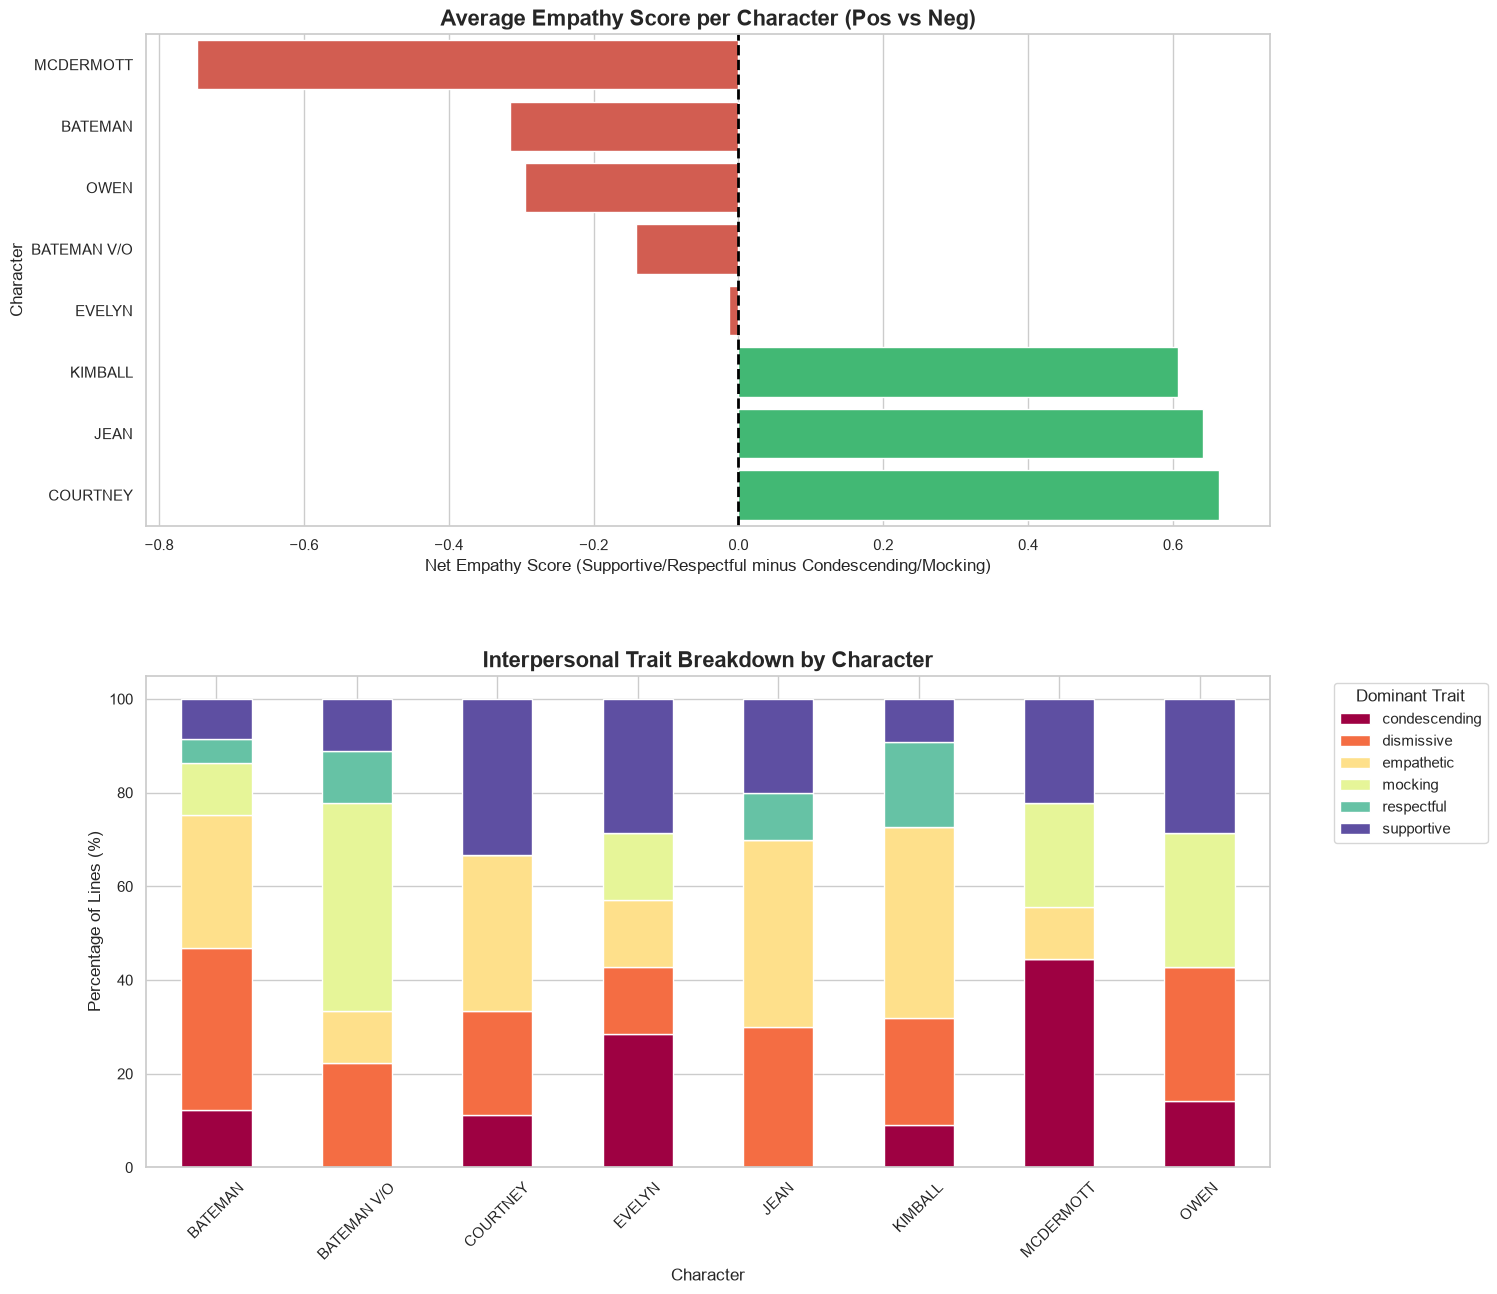

FINAL EMPATHY & INCLUSIVITY REPORT
Highest Empathy/Inclusivity: COURTNEY (Score: 0.66)
Highest Hostility/Exclusivity: MCDERMOTT (Score: -0.75)

Model pipeline complete. Data is ready for IEEE paper figures and abstracts.


In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.tight_layout(pad=7.0)

# Filter for top speaking characters in this sample
top_chars = final_df['Character'].value_counts().head(8).index
plot_df = final_df[final_df['Character'].isin(top_chars)]

# 1. Average Empathy Score by Character
char_empathy = plot_df.groupby('Character')['Empathy_Score'].mean().sort_values()

# Create a color palette: Red for negative empathy (hostile), Green for positive
colors = ['#e74c3c' if score < 0 else '#2ecc71' for score in char_empathy.values]

sns.barplot(
    x=char_empathy.values, 
    y=char_empathy.index, 
    palette=colors,
    ax=axes[0]
)
axes[0].set_title('Average Empathy Score per Character (Pos vs Neg)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Net Empathy Score (Supportive/Respectful minus Condescending/Mocking)', fontsize=12)
axes[0].set_ylabel('Character', fontsize=12)
axes[0].axvline(0, color='black', linewidth=2, linestyle='--') # Zero line

# 2. Distribution of Dominant Interpersonal Traits
# We look at what the most common trait is for these characters
trait_counts = plot_df.groupby(['Character', 'Dominant_Trait']).size().unstack(fill_value=0)
# Normalize to percentages
trait_percentages = trait_counts.div(trait_counts.sum(axis=1), axis=0) * 100

trait_percentages.plot(
    kind='bar', 
    stacked=True, 
    colormap='Spectral', 
    ax=axes[1]
)
axes[1].set_title('Interpersonal Trait Breakdown by Character', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Character', fontsize=12)
axes[1].set_ylabel('Percentage of Lines (%)', fontsize=12)
axes[1].legend(title='Dominant Trait', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.show()

# %% [markdown]
# ## 9. Conclusion & Export Ready

# %%
print("="*60)
print("FINAL EMPATHY & INCLUSIVITY REPORT")
print("="*60)

most_empathetic = char_empathy.idxmax()
most_hostile = char_empathy.idxmin()

print(f"Highest Empathy/Inclusivity: {most_empathetic} (Score: {char_empathy.max():.2f})")
print(f"Highest Hostility/Exclusivity: {most_hostile} (Score: {char_empathy.min():.2f})")
print("\nModel pipeline complete. Data is ready for IEEE paper figures and abstracts.")
print("="*60)